# Procedure Policy Bar Grid (Best-Per-Subset Uncertainty)

This notebook is the same analysis style as `procedure_policy_bar_grid`, but with one change:

- For selected uncertainty policies, subset score is the **best permutation** in that subset
  (min for `iterations_used`, max for dice metrics), not the mean across permutations.
- Other policies (e.g. random baseline) still use subset mean across permutations.

Then dataset-level mean/CI is computed with the same hierarchical bootstrap path (subset -> task -> dataset).


In [7]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys

REPO_ROOT = Path('/data/ddmg/mvseg-ordering')
for path in [REPO_ROOT, REPO_ROOT / 'UniverSeg', REPO_ROOT / 'MultiverSeg', REPO_ROOT / 'ScribblePrompt']:
    if str(path) not in sys.path:
        sys.path.append(str(path))

from experiments.analysis.hierarchical_ci import (
    hierarchical_bootstrap_task_estimates,
    dataset_bootstrap_stats,
)
from experiments.analysis.task_explorer import FAMILY_ROOTS


In [13]:
# -----------------------------
# Config
# -----------------------------
REPO_ROOT = Path('/data/ddmg/mvseg-ordering')
PROCEDURE = 'random_vs_uncertainty_final'
METRIC = 'iterations_used'  # e.g. initial_dice, final_dice, iterations_used

# Optional ablation filter.
ABLATION = None

# Policies to include in plot/summary.
POLICY_ORDER = ['random', 'reverse_curriculum', 'curriculum']
POLICY_DISPLAY_NAMES = {
    'random': 'random',
    'reverse_curriculum': 'easy -> hard',
    'curriculum': 'hard -> easy',
}

# Policies that should use BEST permutation per subset (instead of mean across perms).
BEST_PICK_POLICIES = ['reverse_curriculum', 'curriculum']

# Optional paired-delta view.
DELTA_VS_RANDOM = True
BASELINE_POLICY = 'random'
INCLUDE_BASELINE_IN_PLOT = False

N_BOOT = 2000
SEED = 23
N_COLS = 3

SAVE_FIG = False
FIG_DIR = REPO_ROOT / 'figures' / 'procedure_policy_bar_grid_best_per_subset'

# View controls
ZOOM_MODE = 'local'       # 'none', 'local', or 'global'
ZOOM_PAD_FRAC = 0.20


In [9]:
def load_planb_for_procedure(
    repo_root: Path,
    procedure: str,
    *,
    filename: str = 'subset_support_images_summary.csv',
) -> pd.DataFrame:
    scripts_root = repo_root / 'experiments' / 'scripts' / procedure
    frames: list[pd.DataFrame] = []

    for root_name, family in FAMILY_ROOTS.items():
        family_root = scripts_root / root_name
        if not family_root.exists():
            continue

        for task_dir in sorted(p for p in family_root.iterdir() if p.is_dir()):
            task_id = f'{family}/{task_dir.name}'

            for ablation_dir in sorted(p for p in task_dir.iterdir() if p.is_dir()):
                policy_dirs = sorted(
                    p for p in ablation_dir.iterdir()
                    if p.is_dir() and (p / 'B' / filename).exists()
                )

                if policy_dirs:
                    for policy_dir in policy_dirs:
                        csv_path = policy_dir / 'B' / filename
                        df = pd.read_csv(csv_path)
                        if df.empty:
                            continue
                        df['family'] = family
                        df['task_id'] = task_id
                        df['task_name'] = task_dir.name
                        df['ablation'] = ablation_dir.name
                        df['policy_name'] = policy_dir.name
                        df['__source__'] = str(csv_path)
                        frames.append(df)
                    continue

                csv_path = ablation_dir / 'B' / filename
                if csv_path.exists():
                    df = pd.read_csv(csv_path)
                    if df.empty:
                        continue
                    df['family'] = family
                    df['task_id'] = task_id
                    df['task_name'] = task_dir.name
                    df['ablation'] = ablation_dir.name
                    df['policy_name'] = 'random'
                    df['__source__'] = str(csv_path)
                    frames.append(df)

    if not frames:
        raise FileNotFoundError(
            f'No Plan B summaries found under experiments/scripts/{procedure}/**/{filename}'
        )

    return pd.concat(frames, ignore_index=True)


def policy_sort_key(name: str) -> tuple[int, str]:
    n = str(name)
    try:
        return (POLICY_ORDER.index(n), n)
    except ValueError:
        return (len(POLICY_ORDER) + 1, n)


def is_higher_better(metric_name: str) -> bool:
    return metric_name not in {'iterations_used'}


def build_subset_scores_mixed_strategy(
    family_df: pd.DataFrame,
    *,
    metric: str,
    best_pick_policies: list[str],
) -> pd.DataFrame:
    required = {'task_id', 'subset_index', 'policy_name', 'permutation_index', metric}
    missing = required - set(family_df.columns)
    if missing:
        raise ValueError(f'Missing required columns: {sorted(missing)}')

    # Step 1: one score per permutation (mean across images).
    per_perm = (
        family_df
        .groupby(['task_id', 'subset_index', 'policy_name', 'permutation_index'], as_index=False)[metric]
        .mean()
        .rename(columns={metric: 'perm_score'})
    )

    use_max = is_higher_better(metric)
    rows: list[pd.DataFrame] = []

    for policy_name, grp in per_perm.groupby('policy_name'):
        if str(policy_name) in set(best_pick_policies):
            # Best permutation per (task, subset).
            if use_max:
                subset_stat = (
                    grp.groupby(['task_id', 'subset_index', 'policy_name'], as_index=False)['perm_score']
                    .max()
                    .rename(columns={'perm_score': 'subset_score'})
                )
            else:
                subset_stat = (
                    grp.groupby(['task_id', 'subset_index', 'policy_name'], as_index=False)['perm_score']
                    .min()
                    .rename(columns={'perm_score': 'subset_score'})
                )
        else:
            # Standard expected performance: mean across permutations.
            subset_stat = (
                grp.groupby(['task_id', 'subset_index', 'policy_name'], as_index=False)['perm_score']
                .mean()
                .rename(columns={'perm_score': 'subset_score'})
            )

        rows.append(subset_stat)

    return pd.concat(rows, ignore_index=True)


In [10]:
raw_df = load_planb_for_procedure(REPO_ROOT, PROCEDURE)
print(f'Loaded rows: {len(raw_df):,}')
print('Families:', sorted(raw_df['family'].unique().tolist()))
print('Ablations:', sorted(raw_df['ablation'].unique().tolist()))

if METRIC not in raw_df.columns:
    raise ValueError(f"Metric {METRIC!r} not found. Available columns: {sorted(raw_df.columns)}")

available_ablations = sorted(raw_df['ablation'].astype(str).unique().tolist())
if ABLATION is None:
    if len(available_ablations) == 1:
        active_ablation = available_ablations[0]
    else:
        active_ablation = available_ablations[0]
        print(f"[info] Multiple ablations found: {available_ablations}")
        print(f"[info] Using first by default: {active_ablation}. Set ABLATION to override.")
else:
    active_ablation = str(ABLATION)
    if active_ablation not in available_ablations:
        raise ValueError(f"ABLATION={active_ablation!r} not in available ablations: {available_ablations}")

df = raw_df[raw_df['ablation'].astype(str) == active_ablation].copy()
df = df[df['policy_name'].astype(str).isin(POLICY_ORDER)].copy()

if df.empty:
    raise ValueError(f"No rows left after filtering to POLICY_ORDER={POLICY_ORDER}")

print(f'Using ablation: {active_ablation}')
print('Families in ablation:', sorted(df['family'].unique().tolist()))
print('Policies kept:', sorted(df['policy_name'].astype(str).unique().tolist(), key=policy_sort_key))
print('Best-pick policies:', BEST_PICK_POLICIES)


Loaded rows: 1,613,000
Families: ['ACDC', 'BTCV', 'BUID', 'HipXRay', 'PanDental', 'SCD', 'SCR', 'T1mix', 'TotalSegmentator', 'WBC']
Ablations: ['pretrained_baseline5p']
Using ablation: pretrained_baseline5p
Families in ablation: ['ACDC', 'BTCV', 'BUID', 'HipXRay', 'PanDental', 'SCD', 'SCR', 'T1mix', 'TotalSegmentator', 'WBC']
Policies kept: ['random', 'reverse_curriculum', 'curriculum']
Best-pick policies: ['reverse_curriculum', 'curriculum']


In [11]:
rows: list[dict[str, object]] = []

for family, fam_df in df.groupby('family'):
    subset_scores = build_subset_scores_mixed_strategy(
        fam_df,
        metric=METRIC,
        best_pick_policies=BEST_PICK_POLICIES,
    )

    available = set(subset_scores['policy_name'].astype(str).tolist())
    policies = [p for p in POLICY_ORDER if p in available]

    if DELTA_VS_RANDOM:
        if BASELINE_POLICY not in policies:
            print(f"[warn] family={family}: missing baseline policy={BASELINE_POLICY}; skipping")
            continue

        baseline_subset = (
            subset_scores[subset_scores['policy_name'].astype(str) == BASELINE_POLICY]
            [['task_id', 'subset_index', 'subset_score']]
            .rename(columns={'subset_score': 'baseline_subset_score'})
        )

        rows.append(
            {
                'family': str(family),
                'ablation': active_ablation,
                'metric': METRIC,
                'policy_name': BASELINE_POLICY,
                'mean': 0.0,
                'ci_lo': 0.0,
                'ci_hi': 0.0,
                'n_tasks': int(baseline_subset['task_id'].nunique()),
                'n_subsets': int(len(baseline_subset)),
            }
        )

        for policy_name in policies:
            if policy_name == BASELINE_POLICY:
                continue

            policy_subset = (
                subset_scores[subset_scores['policy_name'].astype(str) == policy_name]
                [['task_id', 'subset_index', 'subset_score']]
                .rename(columns={'subset_score': 'policy_subset_score'})
            )

            paired = policy_subset.merge(
                baseline_subset,
                on=['task_id', 'subset_index'],
                how='inner',
                validate='one_to_one',
            )
            if paired.empty:
                continue

            paired['delta'] = paired['policy_subset_score'] - paired['baseline_subset_score']
            subset_scores_by_task = {
                str(task_id): grp['delta'].to_numpy(dtype=float)
                for task_id, grp in paired.groupby('task_id')
            }

            task_boot = hierarchical_bootstrap_task_estimates(
                subset_scores_by_task,
                n_boot=N_BOOT,
                seed=SEED,
            )
            _, mean, ci_lo, ci_hi = dataset_bootstrap_stats(task_boot, alpha=0.05)

            rows.append(
                {
                    'family': str(family),
                    'ablation': active_ablation,
                    'metric': METRIC,
                    'policy_name': str(policy_name),
                    'mean': float(mean),
                    'ci_lo': float(ci_lo),
                    'ci_hi': float(ci_hi),
                    'n_tasks': int(paired['task_id'].nunique()),
                    'n_subsets': int(len(paired)),
                }
            )

    else:
        for policy_name in policies:
            pol_subset = subset_scores[subset_scores['policy_name'].astype(str) == policy_name].copy()
            subset_scores_by_task = {
                str(task_id): grp['subset_score'].to_numpy(dtype=float)
                for task_id, grp in pol_subset.groupby('task_id')
            }

            task_boot = hierarchical_bootstrap_task_estimates(
                subset_scores_by_task,
                n_boot=N_BOOT,
                seed=SEED,
            )
            _, mean, ci_lo, ci_hi = dataset_bootstrap_stats(task_boot, alpha=0.05)

            rows.append(
                {
                    'family': str(family),
                    'ablation': active_ablation,
                    'metric': METRIC,
                    'policy_name': str(policy_name),
                    'mean': float(mean),
                    'ci_lo': float(ci_lo),
                    'ci_hi': float(ci_hi),
                    'n_tasks': int(pol_subset['task_id'].nunique()),
                    'n_subsets': int(len(pol_subset)),
                }
            )

summary_df = pd.DataFrame(rows)
if not summary_df.empty:
    summary_df['policy_name'] = pd.Categorical(summary_df['policy_name'], categories=POLICY_ORDER, ordered=True)
    summary_df = summary_df.sort_values(['family', 'policy_name']).reset_index(drop=True)
    summary_df['policy_name'] = summary_df['policy_name'].astype(str)

summary_df


[warn] family=TotalSegmentator: missing baseline policy=random; skipping


,family,ablation,metric,policy_name,mean,ci_lo,ci_hi,n_tasks,n_subsets
0,ACDC,pretrained_baseline5p,iterations_used,random,0.000000,0.000000,0.000000,6,60
1,ACDC,pretrained_baseline5p,iterations_used,reverse_curriculum,-0.253278,-0.288552,-0.222829,6,60
2,ACDC,pretrained_baseline5p,iterations_used,curriculum,-0.252739,-0.311340,-0.201228,6,60
3,BTCV,pretrained_baseline5p,iterations_used,random,0.000000,0.000000,0.000000,20,200
4,BTCV,pretrained_baseline5p,iterations_used,reverse_curriculum,-0.383225,-0.396796,-0.369059,20,200
5,BTCV,pretrained_baseline5p,iterations_used,curriculum,-0.363420,-0.381081,-0.346244,20,200
6,BUID,pretrained_baseline5p,iterations_used,random,0.000000,0.000000,0.000000,4,40
7,BUID,pretrained_baseline5p,iterations_used,reverse_curriculum,-0.357358,-0.387105,-0.325494,4,40
8,BUID,pretrained_baseline5p,iterations_used,curriculum,-0.246600,-0.297955,-0.197095,4,40
9,HipXRay,pretrained_baseline5p,iterations_used,random,0.000000,0.000000,0.000000,4,40


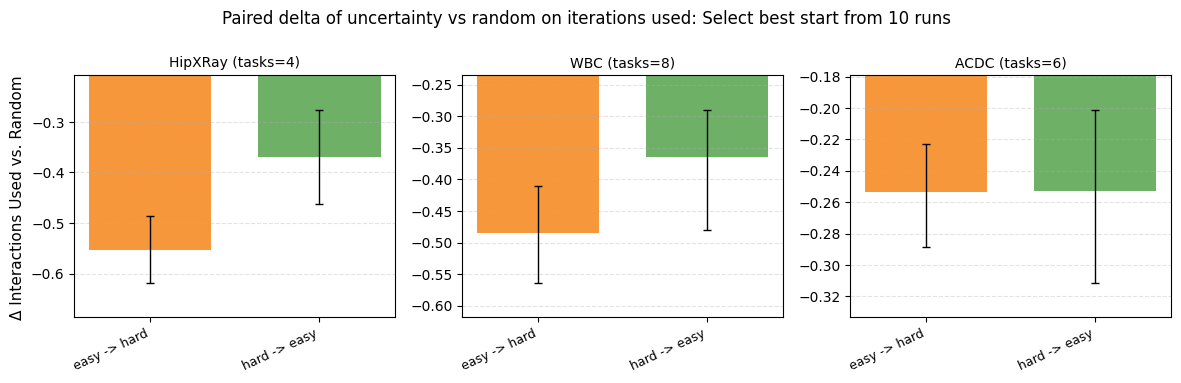

In [21]:
def plot_dataset_bar_grid(summary_df: pd.DataFrame) -> None:
    if summary_df.empty:
        print('No summary rows to plot.')
        return

    zoom_mode = str(ZOOM_MODE).strip().lower()
    if zoom_mode not in {'none', 'local', 'global'}:
        raise ValueError(f"Unsupported ZOOM_MODE={ZOOM_MODE!r}. Use 'none', 'local', or 'global'.")

    families = sorted(summary_df['family'].unique().tolist())
    policy_order = [p for p in POLICY_ORDER if p in set(summary_df['policy_name'].astype(str).tolist())]
    if not INCLUDE_BASELINE_IN_PLOT and BASELINE_POLICY in policy_order:
        policy_order = [p for p in policy_order if p != BASELINE_POLICY]
    if not policy_order:
        raise ValueError('No policies left to plot after applying INCLUDE_BASELINE_IN_PLOT filter.')

    policy_colors = {
        'random': '#4C78A8',
        'reverse_curriculum': '#F58518',
        'curriculum': '#54A24B',
    }

    n_families = len(families)
    n_cols = 3
    n_rows = 1

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.0 * n_cols, 3.8 * n_rows), squeeze=False)
    axes_flat = axes.ravel()

    global_lo = float(summary_df['ci_lo'].min())
    global_hi = float(summary_df['ci_hi'].max())
    global_span = max(global_hi - global_lo, 1e-8)
    global_pad = ZOOM_PAD_FRAC * global_span
    y_label = f'Δ Interactions Used vs. Random'
    fig.supylabel(y_label, fontsize=11, x=0.02)

    for i, family in enumerate(['HipXRay', 'WBC', 'ACDC']):
        ax = axes_flat[i]
        fam = summary_df[summary_df['family'] == family].copy()
        fam = fam[fam['policy_name'].astype(str).isin(policy_order)].copy()
        fam['policy_name'] = pd.Categorical(fam['policy_name'], categories=policy_order, ordered=True)
        fam = fam.sort_values('policy_name').reset_index(drop=True)
        if fam.empty:
            ax.axis('off')
            continue

        x = np.arange(len(fam), dtype=float)
        means = fam['mean'].to_numpy(dtype=float)
        ci_lo = fam['ci_lo'].to_numpy(dtype=float)
        ci_hi = fam['ci_hi'].to_numpy(dtype=float)
        err_lo = means - ci_lo
        err_hi = ci_hi - means

        colors = [policy_colors.get(str(p), '#777777') for p in fam['policy_name'].tolist()]
        ax.bar(x, means, color=colors, alpha=0.85, width=0.72)
        ax.errorbar(x, means, yerr=np.vstack([err_lo, err_hi]), fmt='none', ecolor='black', capsize=3, linewidth=1)

        if DELTA_VS_RANDOM:
            ax.axhline(0.0, color='black', linestyle='--', linewidth=1.0, alpha=0.8)

        if zoom_mode == 'local':
            lo = float(ci_lo.min())
            hi = float(ci_hi.max())
            span = max(hi - lo, 1e-8)
            pad = ZOOM_PAD_FRAC * span
            ax.set_ylim(lo - pad, hi + pad)
        elif zoom_mode == 'global':
            ax.set_ylim(global_lo - global_pad, global_hi + global_pad)

        ax.set_title(f"{family} (tasks={int(fam['n_tasks'].max())})", fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(
            [POLICY_DISPLAY_NAMES.get(str(p), str(p)) for p in fam['policy_name'].tolist()],
            rotation=25,
            ha='right',
            fontsize=9,
        )
        ax.grid(axis='y', linestyle='--', alpha=0.35)

    for j in range(n_families, len(axes_flat)):
        axes_flat[j].axis('off')

    metric_name = str(summary_df['metric'].iloc[0])
    ablation_name = str(summary_df['ablation'].iloc[0])
    if DELTA_VS_RANDOM:
        title = (
            f"Paired delta of uncertainty vs random on {metric_name.replace('_', ' ')}: "
            f"Select best start from 10 runs"
        )
    else:
        title = (
            f"{metric_name} (best-per-subset uncertainty): "
            f"hierarchical bootstrap mean/CI by policy ({PROCEDURE}, {ablation_name})"
        )

    fig.suptitle(title, fontsize=12, y=0.995)
    fig.tight_layout()

    if SAVE_FIG:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        mode_tag = 'paired_delta' if DELTA_VS_RANDOM else 'absolute'
        zoom_tag = zoom_mode
        out_path = FIG_DIR / f"{PROCEDURE.replace('/', '_')}_{ablation_name}_{metric_name}_best_subset_{mode_tag}_{zoom_tag}_bar_grid.png"
        fig.savefig(out_path, dpi=180, bbox_inches='tight')
        print(f'saved: {out_path}')

    plt.show()


plot_dataset_bar_grid(summary_df)
